
# Försäkringskostnadsprediktion

I den här uppgiften ska vi använda information som en persons ålder, kön, BMI, antal barn och rökvanor för att förutsäga priset på årliga medicinska räkningar. Den här typen av modell är användbar för försäkringsbolag för att bestämma den årliga försäkringspremien för en person. Datamängden för detta problem är hämtad från: https://www.kaggle.com/mirichoi0218/insurance

Vi kommer att skapa en modell med följande steg:

* Hämta och utforska datamängden
* Förbered datamängden för träning
* Skapa en icke-linjär regressionsmodell med pytorch
* Träna modellen för att passa data
* Göra förutsägelser med den tränade modellen


In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split

### Steg 1: Ladda in och utforska datan

In [2]:
fil = 'insurance.csv'

In [3]:
data = pd.read_csv(fil)

In [4]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#### Vad mer kan vi säga om datan?

In [5]:
print(data.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


* **Q: Hur många rader har finns i datan?**
* **Q: Vilka kolumner finns i datan?**

In [6]:
print(data.shape)

(1338, 7)


In [7]:
print(data.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


* **Q Finns det rader med null-värden?**

In [8]:
print(data.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


### Steg 2: Förbered datan för träning

Datan innehåller kategoriska variabler som `sex` och `smoker`. Vi måste konvertera dessa till numeriska värden innan vi kan träna vår modell. Vi måste också konvertera datan till en form som kan användas för att träna en pytorch modell.

Vår target/y-värde kommer att vara `charges` kolumnen. Vi måste separera detta från resten av datan.

In [11]:
input_cols = ['age', 'sex', 'bmi', 'children', 'smoker']
output_cols = ['charges']
categorical = ['smoker', 'sex']

In [12]:
def dataframe_to_arrays(dataframe, input_cols, output_cols, categorical_cols):
    # En kopiering av dataframe
    dataframe1 = dataframe.copy(deep=True)
    # Konverter kategoriske kolonner til tall
    for col in categorical_cols:
        dataframe1[col] = dataframe1[col].astype('category').cat.codes
    # Extrahera input och output arrays
    inputs_array = dataframe1[input_cols].to_numpy()
    targets_array = dataframe1[output_cols].to_numpy()
    return inputs_array, targets_array

In [13]:
inputs_array, targets_array = dataframe_to_arrays(data, input_cols, output_cols, categorical)

In [14]:
inputs_array

array([[19.  ,  0.  , 27.9 ,  0.  ,  1.  ],
       [18.  ,  1.  , 33.77,  1.  ,  0.  ],
       [28.  ,  1.  , 33.  ,  3.  ,  0.  ],
       ...,
       [18.  ,  0.  , 36.85,  0.  ,  0.  ],
       [21.  ,  0.  , 25.8 ,  0.  ,  0.  ],
       [61.  ,  0.  , 29.07,  0.  ,  1.  ]])

In [15]:
targets_array

array([[16884.924 ],
       [ 1725.5523],
       [ 4449.462 ],
       ...,
       [ 1629.8335],
       [ 2007.945 ],
       [29141.3603]])

Visa histogram över vår target

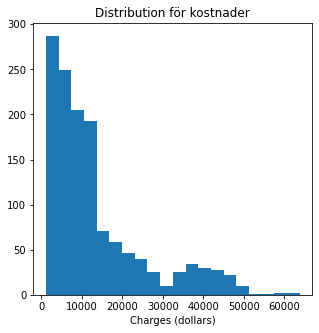

In [16]:
#Visa histogram över vår target
plt.figure(figsize=(5, 5))
plt.hist(targets_array, bins=20)
plt.xlabel('Charges (dollars)')
plt.title('Distribution för kostnader')
plt.show()

Visa histogram över vår input

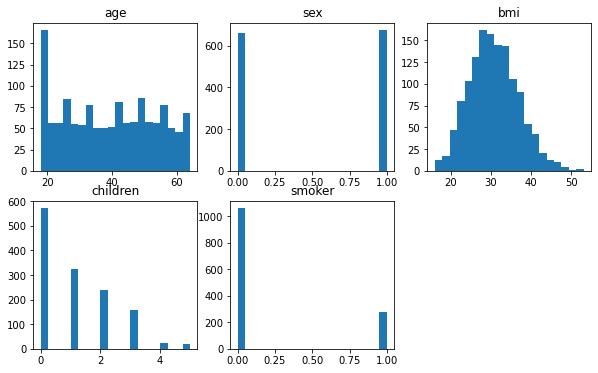

In [19]:
plt.figure(figsize=(10, 6))
for i, col in enumerate(input_cols):
    plt.subplot(2, 3, i+1)
    plt.hist(inputs_array[:, i], bins=20)
    plt.title(col)

#### Konvertera vår data till en form som kan användas för att träna en pytorch modell

In [20]:
inputs = torch.from_numpy(inputs_array).type(torch.float32)
targets = torch.from_numpy(targets_array).type(torch.float32)

Nästa steg är att skapa PyTorch-dataset och dataladdare för träning och validering. Vi börjar med att skapa en TensorDataset.

In [22]:
dataset = TensorDataset(inputs, targets)

För att skapa tränings- och valideringsdataset med önskad storlek kan vi använda `random_split`-funktionen från PyTorch. 

Den delar upp datamängden i två delar med specificerade storlekar. Här är hur du kan göra det:

In [23]:
num_rows = len(data)

val_percent = 0.1  # mellan 0.1 och 0.2 är ofta rimligt.
val_size = int(num_rows * val_percent)
train_size = num_rows - val_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

#### Skapa en dataladdare

In [26]:
batch_size = 32 # Dvs. hur många exempel som ska användas för att uppdatera vikterna vid varje iteration

In [27]:
train_loader = DataLoader(train_ds, batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size)

Loopa över en batch från dataladdaren för träning

In [28]:
for batch in train_loader:
    inputs, targets = batch
    print("Inputs:", inputs)
    print("Targets:", targets)
    break  # Endast titta på den första satsen för att undvika att skriva ut all data

Inputs: tensor([[49.0000,  0.0000, 21.3000,  1.0000,  0.0000],
        [54.0000,  1.0000, 29.2000,  1.0000,  0.0000],
        [57.0000,  0.0000, 30.4950,  0.0000,  0.0000],
        [31.0000,  1.0000, 25.9000,  3.0000,  1.0000],
        [40.0000,  0.0000, 41.4200,  1.0000,  0.0000],
        [31.0000,  0.0000, 29.1000,  0.0000,  0.0000],
        [28.0000,  0.0000, 37.6200,  1.0000,  0.0000],
        [36.0000,  0.0000, 22.1350,  3.0000,  0.0000],
        [44.0000,  0.0000, 23.9800,  2.0000,  0.0000],
        [27.0000,  0.0000, 24.1000,  0.0000,  0.0000],
        [23.0000,  1.0000, 35.2000,  1.0000,  0.0000],
        [38.0000,  1.0000, 16.8150,  2.0000,  0.0000],
        [58.0000,  0.0000, 36.4800,  0.0000,  0.0000],
        [21.0000,  0.0000, 32.6800,  2.0000,  0.0000],
        [64.0000,  0.0000, 26.8850,  0.0000,  1.0000],
        [44.0000,  0.0000, 27.5000,  1.0000,  0.0000],
        [23.0000,  0.0000, 28.0000,  0.0000,  0.0000],
        [62.0000,  1.0000, 37.4000,  0.0000,  0.0000],
  

### Steg 3: Skapa en modell för att prediktera försäkringskostnader

In [29]:
input_size = len(input_cols)
output_size = len(output_cols)

print(input_size, output_size)

5 1


In [30]:
N = 64
model = nn.Sequential(
    nn.Linear(input_size, N),
    nn.ReLU(),
    nn.Linear(N, N),
    nn.ReLU(),
    nn.Linear(N, N),
    nn.ReLU(),
    nn.Linear(N, output_size)
)

In [31]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {total_params}")

Number of parameters: 8769


### Steg 4: Träna modellen

Vi ska nu träna vår modell.

Träningen går till som så att vi tränar på datan som kommer från träningsladdaren, men samtidigt validerar vi på data från valideringsinladdaren. På så sätt är vårat mål att hitta en modell som generaliserar bättre.

In [32]:
def validera(model, valideringsladdare, förlustfunktion):
    """Funktion för att validera modellen på valideringsdata."""
    total_loss = 0
    total_items = 0

    #vi vill inte uppdatera vikterna när vi validerar
    with torch.no_grad():
        for batch in valideringsladdare:
            inputs, targets = batch
            predictions = model(inputs)
            loss = förlustfunktion(predictions, targets)
            total_loss += loss.mean().item()
            total_items += 1
    return total_loss/total_items


In [33]:
def träna(epoker, model, träningsladdare, valideringsladdare, optimerare, förlustfunktion):
    """Funktion för att träna en modell och validera den efter varje epok."""
    h_val = []
    h_train = []

    #Loopa över epoker
    for e in range(epoker):
        for batch in träningsladdare:
            inputs, targets = batch
            predictions = model(inputs)
            förlust = förlustfunktion(predictions, targets)
            förlust.backward()
            optimerare.step()
            optimerare.zero_grad()

        #Validera modellen på data som den inte är tränad på.
        if e % 10 == 0:
            result_val = validera(model, valideringsladdare, förlustfunktion)
            result = validera(model, träningsladdare, förlustfunktion)
            print("Epok [{}/{}], valideringsförlust: {:.4f}".format(e+1, epoker, result))
            h_val.append(result_val)
            h_train.append(result)

    
    return h_val, h_train 

In [34]:
epoker = 200
lr = 1e-1
förlustfunktion = torch.nn.L1Loss()#L1 loss // MAE loss np.abs(predictions-targets)
optimerare = torch.optim.Adam(model.parameters(), lr=lr)

In [35]:
resultat_val, resultat_train = träna(epoker, model, train_loader, val_loader, optimerare, förlustfunktion)

Epok [1/200], valideringsförlust: 6478.1430
Epok [11/200], valideringsförlust: 3517.7477
Epok [21/200], valideringsförlust: 2336.0979
Epok [31/200], valideringsförlust: 2844.1621
Epok [41/200], valideringsförlust: 2385.8118
Epok [51/200], valideringsförlust: 2595.5612
Epok [61/200], valideringsförlust: 2454.3536
Epok [71/200], valideringsförlust: 2383.3196
Epok [81/200], valideringsförlust: 2320.5624
Epok [91/200], valideringsförlust: 2638.3338
Epok [101/200], valideringsförlust: 1823.3112
Epok [111/200], valideringsförlust: 2377.7287
Epok [121/200], valideringsförlust: 2134.4746
Epok [131/200], valideringsförlust: 1779.2079
Epok [141/200], valideringsförlust: 2469.5662
Epok [151/200], valideringsförlust: 2079.7132
Epok [161/200], valideringsförlust: 1638.2254
Epok [171/200], valideringsförlust: 2405.7363
Epok [181/200], valideringsförlust: 1710.5955
Epok [191/200], valideringsförlust: 1766.5269


Text(0.5, 1.0, 'Fel vs. antal epoker')

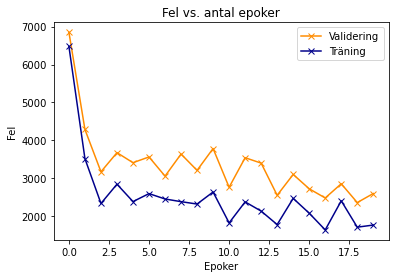

In [36]:
val_loss = resultat_val
train_loss = resultat_train
plt.plot(val_loss, '-x', label='Validering', color = 'darkorange')
plt.plot(train_loss, '-x', label='Träning', color = 'darkblue')
plt.legend()
plt.xlabel('Epoker')
plt.ylabel('Fel')
plt.title('Fel vs. antal epoker')

### Steg 5: Gör förutsägelser med den tränade modellen och utvärdera modellen

In [37]:
def prediktera_en_person(input, target, model):
    inputs = input.unsqueeze(0)
    predictions = model(inputs)
    prediction = predictions[0].detach()
    print("Input:", input)
    print("Label:", target[0].item())
    print("Prediktion:", prediction[0].item())
    print("Fel:", (target[0] - prediction[0]).item())

In [38]:
input_cols

['age', 'sex', 'bmi', 'children', 'smoker']

In [39]:
prediktera_en_person(*val_ds[0], model)

Input: tensor([19.0000,  1.0000, 20.6150,  2.0000,  0.0000])
Label: 2803.69775390625
Prediktion: 2505.608642578125
Fel: 298.089111328125


In [40]:
prediktera_en_person(*val_ds[4], model)

Input: tensor([48.0000,  0.0000, 36.5750,  0.0000,  0.0000])
Label: 8671.19140625
Prediktion: 8155.59423828125
Fel: 515.59716796875


#### Visualisera felet med en scatter-plot för valideringsdatan

In [42]:
prediktioner = np.concatenate([model(inputs).detach().numpy() for inputs, _ in val_loader])
targets = np.concatenate([targets for _, targets in val_loader])


Text(0.5, 1.0, 'Riktiga kostnader vs. Predikterade kostnader')

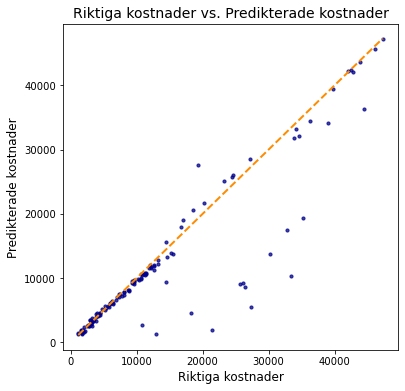

In [43]:
plt.figure(figsize=(6, 6))
plt.scatter(targets, prediktioner, s=10, color='darkblue', alpha=0.75)
# En linje där x = y
plt.plot([np.min(targets), np.max(targets)], [np.min(targets), np.max(targets)], color='darkorange', linewidth=2, linestyle='--', label='x = y')
plt.xlabel('Riktiga kostnader', fontsize=12)
plt.ylabel('Predikterade kostnader', fontsize=12)
plt.title('Riktiga kostnader vs. Predikterade kostnader', fontsize=14)


Text(0.5, 1.0, 'Riktiga kostnader vs. Predikterade kostnader')

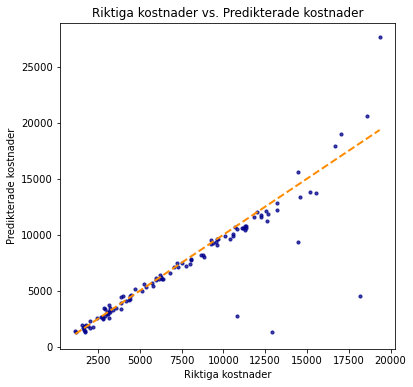

In [44]:
idx = targets<20000
targets = targets[idx]
prediktioner = prediktioner[idx]

plt.figure(figsize=(6, 6))
plt.scatter(targets, prediktioner, s=10, color='darkblue', alpha=0.75)
# En linje där x = y
plt.plot([np.min(targets), np.max(targets)], [np.min(targets), np.max(targets)], color='darkorange', linewidth=2, linestyle='--', label='x = y')
plt.xlabel('Riktiga kostnader')
plt.ylabel('Predikterade kostnader')
plt.title('Riktiga kostnader vs. Predikterade kostnader')

#### Summering

Vi har skapat en modell som kan förutsäga försäkringskostnader baserat på en persons ålder, kön, BMI, antal barn och rökvanor. Vi har tränat modellen och gjort förutsägelser med den. Vi har också utvärderat modellen genom att jämföra de förutsagda värdena med de verkliga värdena.

Vi kan använda denna modell för att förutsäga försäkringskostnader för nya personer. Om vi har information om en persons ålder, kön, BMI, antal barn och rökvanor kan vi mata in dessa värden i modellen och få en uppskattning av deras årliga försäkringskostnader.

Andra saker att kolla på och optimera:

* Normalisera datan så den t ex. är mellan 0-1
* Ta bort outliers
* Ändra arkitektur på nätverket
* Regularisera på olika sätt för att förhindra överträning
 

In [45]:
#Spara modellen
torch.save(model, 'försäkringsmodel.pt')

# Ladda in modellen
model_tränad = torch.load('försäkringsmodel.pt')